# Regresión Lineal - Accidentes de tránsito en Bogotá

## Notebook 3: Entrenamiento y evaluación del modelo

Continúa desde `02_agregacion_features.ipynb`. Parte de `data/processed/accidentes_diarios_localidad.csv` (serie diaria de accidentes por localidad, con features de fecha) y entrena un modelo de regresión lineal.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

sys.path.append(str(Path.cwd().parent))
from models.linear_regresion import generate_model

ruta_datos = Path.cwd().parent / "data" / "processed" / "accidentes_diarios_localidad.csv"
all_registers = pd.read_csv(ruta_datos, parse_dates=["fecha"])
all_registers.shape

(46455, 6)

## 1. Filtrar el periodo pre-pandemia

Como vimos en el notebook 2, la cuarentena estricta de 2020 introdujo una caída anómala en los accidentes. Para no ensuciar el aprendizaje del modelo con ese evento atípico, trabajamos solo con fechas anteriores al 1 de marzo de 2020.

In [2]:
all_registers_pre_pandemia = all_registers[all_registers['fecha'] < '2020-03-01'].copy()
all_registers_pre_pandemia.shape

(35834, 6)

## 2. Split cronológico (train/test)

No usamos un split aleatorio porque estamos trabajando con una serie de tiempo: entrenar con fechas mezcladas al azar dejaría que el modelo "viera" información cercana a las fechas de prueba (fuga de información), inflando artificialmente su desempeño.

En vez de cortar por posición de fila, sacamos primero las fechas únicas y buscamos la fecha que marca el percentil 80. Así garantizamos que todas las localidades de un mismo día queden juntas del mismo lado del split (nunca un día partido entre train y test).

In [3]:
unique_dates = all_registers_pre_pandemia['fecha'].drop_duplicates().sort_values()
date_for_cut = unique_dates.iloc[int(len(unique_dates) * 0.8)]

train_mask = all_registers_pre_pandemia['fecha'] < date_for_cut
test_mask = all_registers_pre_pandemia['fecha'] >= date_for_cut

df_train = all_registers_pre_pandemia[train_mask]
df_test = all_registers_pre_pandemia[test_mask]

print("Fecha de corte:", date_for_cut)
print("Train:", df_train.shape, "| Test:", df_test.shape)

Fecha de corte: 2019-02-17 00:00:00
Train: (28652, 6) | Test: (7182, 6)


## 3. Codificación de variables categóricas

Convertimos `dia_semana` y `LOCALIDAD` a variables dummy (one-hot) con `drop_first=True` para evitar la trampa de las variables dummy (colinealidad perfecta con el intercepto).

**Cuidado:** como codificamos `df_train` y `df_test` por separado, si alguna categoría de `dia_semana` o `LOCALIDAD` apareciera en un conjunto pero no en el otro, `X_train` y `X_test` terminarían con columnas distintas (el modelo fallaría al predecir). Verificamos abajo que esto no ocurra.

In [4]:
X_train = pd.get_dummies(df_train[['mes', 'anio', 'dia_semana', 'LOCALIDAD']], columns=['dia_semana', 'LOCALIDAD'], drop_first=True)
X_test = pd.get_dummies(df_test[['mes', 'anio', 'dia_semana', 'LOCALIDAD']], columns=['dia_semana', 'LOCALIDAD'], drop_first=True)

Y_train = df_train['num_accidentes']
Y_test = df_test['num_accidentes']

print("Columnas solo en train:", set(X_train.columns) - set(X_test.columns))
print("Columnas solo en test:", set(X_test.columns) - set(X_train.columns))

Columnas solo en train: set()
Columnas solo en test: set()


## 4. Entrenamiento del modelo

`generate_model` (en `src/models/linear_regresion.py`) entrena una `LinearRegression`, calcula las métricas de evaluación sobre el set de prueba y retorna el modelo ya entrenado:
- **R²**: qué proporción de la variabilidad de `num_accidentes` explica el modelo (1.0 = perfecto, 0.0 = no explica nada).
- **MAE**: error absoluto promedio, en la misma unidad que `num_accidentes` (accidentes).
- **RMSE**: similar al MAE pero penaliza más los errores grandes.

In [5]:
model = generate_model(X_train, Y_train, X_test, Y_test)

R²: 0.5679
MAE: 1.8980
RMSE: 2.4982


## 5. Coeficientes del modelo

Cada coeficiente indica cuánto cambia la predicción de `num_accidentes` por cada unidad de esa variable (o, en el caso de las dummies, comparado contra la categoría de referencia que se dejó fuera con `drop_first`).

In [6]:
coeficientes = pd.Series(model.coef_, index=X_train.columns).sort_values(ascending=False)
coeficientes

LOCALIDAD_KENNEDY               8.541777
LOCALIDAD_ENGATIVA              7.818966
LOCALIDAD_USAQUEN               7.209549
LOCALIDAD_SUBA                  7.003316
LOCALIDAD_FONTIBON              5.584881
LOCALIDAD_PUENTE ARANDA         4.358090
LOCALIDAD_CHAPINERO             4.027851
LOCALIDAD_TEUSAQUILLO           3.127321
LOCALIDAD_BARRIOS UNIDOS        3.102122
LOCALIDAD_BOSA                  2.250000
LOCALIDAD_CIUDAD BOLIVAR        1.762599
LOCALIDAD_LOS MARTIRES          1.171751
LOCALIDAD_SANTA FE              0.823607
LOCALIDAD_TUNJUELITO            0.645889
LOCALIDAD_RAFAEL URIBE URIBE    0.639920
LOCALIDAD_SAN CRISTOBAL         0.557029
anio                            0.210241
LOCALIDAD_USME                  0.131963
mes                             0.057667
dia_semana_Tuesday             -0.194313
dia_semana_Wednesday           -0.304636
dia_semana_Saturday            -0.334692
dia_semana_Thursday            -0.372658
dia_semana_Monday              -0.741555
LOCALIDAD_CANDEL

## 6. Diagnóstico de residuos

Los residuos (`Y_test - Y_pred`) nos dicen si el modelo tiene sesgos sistemáticos. Idealmente deberían distribuirse de forma aleatoria alrededor de cero, sin ningún patrón.

In [7]:
Y_pred = model.predict(X_test)
residuos = Y_test - Y_pred

### Residuos vs valores predichos

**Qué representa:** busca detectar patrones no capturados por el modelo. Si los puntos se ven dispersos aleatoriamente alrededor de la línea roja (residuo = 0), el modelo no tiene sesgos sistemáticos. Si se ve una forma de embudo o una curva, indica que el modelo no captura bien alguna relación (por ejemplo, subestima sistemáticamente los días con muchos accidentes).

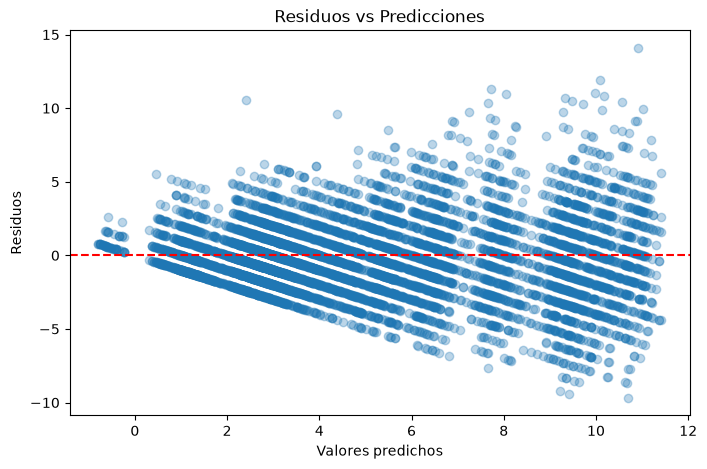

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(Y_pred, residuos, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Residuos vs Predicciones')
plt.show()

### Distribución de los residuos

**Qué representa:** busca confirmar que los errores del modelo se distribuyen aproximadamente de forma normal y centrada en cero (supuesto clásico de la regresión lineal). Un histograma muy sesgado o con colas largas sugiere que el modelo comete errores grandes en ciertos casos particulares.

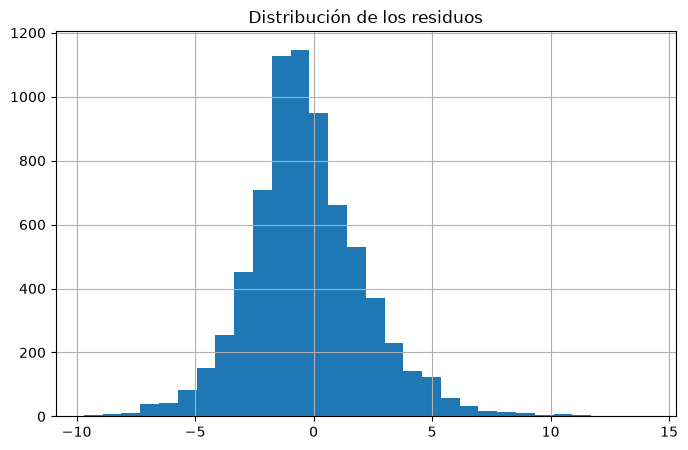

In [8]:
plt.figure(figsize=(8,5))
residuos.hist(bins=30)
plt.title('Distribución de los residuos')
plt.show()

In [ ]:
residuos.describe()

**Cómo leer este resumen:** la `mean` debería estar cerca de 0 (sin sesgo sistemático hacia sobre o subestimar). `std` es comparable al RMSE reportado por `generate_model`. `min`/`max` muestran los peores errores puntuales del modelo (útil para detectar días-localidad atípicos que el modelo no logra capturar).

## 7. Conclusiones y limitaciones

**Desempeño del modelo:**
- **R² ≈ 0.57**: el modelo explica poco más de la mitad de la variabilidad diaria de accidentes por localidad. Es un punto de partida razonable, pero deja bastante margen de mejora.
- **MAE ≈ 1.9 / RMSE ≈ 2.5**: en promedio el modelo se equivoca por 2 accidentes por combinación día-localidad; el RMSE algo mayor que el MAE indica presencia de algunos errores grandes puntuales (coherente con lo visto en `residuos.describe()`).

**Qué explica más al modelo (coeficientes):**
- `LOCALIDAD` domina claramente: el rango entre Kennedy (la de mayor coeficiente) y Candelaria (la de menor) es de casi 10 accidentes diarios. El tamaño y volumen de tráfico de cada localidad es, con diferencia, el factor más determinante.
- `dia_semana`: domingo y lunes tienen los coeficientes más negativos (menos accidentes que el resto de la semana), consistente con un menor flujo vehicular ese día.
- `mes` y `anio` aportan señal comparativamente débil frente a `LOCALIDAD`.

**Limitaciones y posibles próximos pasos:**
- `num_accidentes` es una variable de **conteo**, no continua; modelos como Poisson o binomial negativa suelen ajustar mejor este tipo de target que una regresión lineal ordinaria, sobre todo si hay sobredispersión.
- No se incluyeron variables externas con potencial impacto real: clima, días festivos, eventos masivos, obras viales o pico y placa.
- El modelo se entrenó solo con datos pre-pandemia (antes de 2020-03-01) y **no es válido** para el período de cuarentena ni para escenarios similares de restricción de movilidad.
- El R² moderado sugiere que la relación no es puramente lineal; valdría la pena comparar contra modelos no lineales (árboles de decisión, gradient boosting) o probar interacciones explícitas (p. ej. `LOCALIDAD` x `dia_semana`).

Este mismo pipeline (limpieza → agregación → features → modelo → diagnóstico de residuos) está productizado como script en `src/main.py`, que además guarda todas las figuras generadas en `reports/figures/` para el reporte final.